<center>
  <h1 style='color:green;'> Genomics of Drug Sensitivity in Cancer (GDSC)</h1>
    <h2>Exploratory Data Analysis</h2>
    <h3>HackBio AI for Genomics Internship</h3>
    <h4>Team valine-asparagine-alanin</h4>
    <h4>Uncovering drug response patterns, cancer-type sensitivity profiles, and genomic biomarkers of pharmacological outcome</h4>
</center>


**Dataset:** <a href = 'https://github.com/HackBio-Internship/public_datasets/raw/refs/heads/main/GDSC.xlsx'>GDSC Public Repository </a>


## Objective

This notebook performs an exploratory analysis of the GDSC dataset to identify:

- Drug sensitivity patterns
- Cancer-specific therapeutic responses
- Highly selective anti-cancer drugs
- Genomic determinants of drug response
- Precision oncology insights



## Scientific Background

The Genomics of Drug Sensitivity in Cancer (GDSC) project links:
- Cancer cell lines
- Genomic features
- Drug response measurements

The aim is to understand how tumour molecular profiles influence therapeutic sensitivity.



import the necessary libraries and the GDSC dataset

## Setup & Data Loading

In [49]:
import numpy as np
import pandas as pd

In [50]:
gdsc = pd.read_excel("GDSC.xlsx")

In [51]:
gdsc.head()

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,687448,COLO-829,SKCM,1003,Camptothecin,-1.235034,0.867348,0.557727,skin,melanoma,SKCM,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,687455,RT4,BLCA,1003,Camptothecin,-2.963191,0.821438,-0.383200,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
3,687457,SW780,BLCA,1003,Camptothecin,-1.449138,0.905050,0.441154,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
4,687459,TCCSUP,BLCA,1003,Camptothecin,-2.350633,0.843430,-0.049682,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication


In [52]:
gdsc.shape
gdsc.columns
gdsc.info()
gdsc.describe()
gdsc["DRUG_NAME"].nunique()
gdsc["TCGA_DESC"].nunique()
gdsc["CELL_LINE_NAME"].nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162103 entries, 0 to 162102
Data columns (total 19 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   COSMIC_ID                                162103 non-null  int64  
 1   CELL_LINE_NAME                           162103 non-null  object 
 2   TCGA_DESC                                162103 non-null  object 
 3   DRUG_ID                                  162103 non-null  int64  
 4   DRUG_NAME                                162103 non-null  object 
 5   LN_IC50                                  162103 non-null  float64
 6   AUC                                      162103 non-null  float64
 7   Z_SCORE                                  162103 non-null  float64
 8   GDSC Tissue descriptor 1                 162103 non-null  object 
 9   GDSC Tissue descriptor 2                 162103 non-null  object 
 10  Cancer Type (matching TCGA label

737

In [53]:
missing = gdsc.isnull().sum().sort_values(ascending=False)
missing.head(20)

COSMIC_ID                                  0
CELL_LINE_NAME                             0
TCGA_DESC                                  0
DRUG_ID                                    0
DRUG_NAME                                  0
LN_IC50                                    0
AUC                                        0
Z_SCORE                                    0
GDSC Tissue descriptor 1                   0
GDSC Tissue descriptor 2                   0
Cancer Type (matching TCGA label)          0
Microsatellite instability Status (MSI)    0
Screen Medium                              0
Growth Properties                          0
CNA                                        0
Gene Expression                            0
Methylation                                0
TARGET                                     0
TARGET_PATHWAY                             0
dtype: int64

In [54]:
gdsc = gdsc.drop_duplicates()
gdsc

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,687448,COLO-829,SKCM,1003,Camptothecin,-1.235034,0.867348,0.557727,skin,melanoma,SKCM,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,687455,RT4,BLCA,1003,Camptothecin,-2.963191,0.821438,-0.383200,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
3,687457,SW780,BLCA,1003,Camptothecin,-1.449138,0.905050,0.441154,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
4,687459,TCCSUP,BLCA,1003,Camptothecin,-2.350633,0.843430,-0.049682,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162098,1659818,MM1S,MM,2499,N-acetyl cysteine,9.316959,0.988236,-0.775041,myeloma,myeloma,MM,MSS/MSI-L,R,Suspension,Y,Y,Y,Metabolism,Metabolism
162099,1659928,SNU-175,COREAD,2499,N-acetyl cysteine,10.127082,0.976746,0.156872,large_intestine,large_intestine,COAD/READ,MSI-H,R,Suspension,Y,Y,Y,Metabolism,Metabolism
162100,1660034,SNU-407,COREAD,2499,N-acetyl cysteine,8.576377,0.913378,-1.626959,large_intestine,large_intestine,COAD/READ,MSI-H,R,Adherent,Y,Y,Y,Metabolism,Metabolism
162101,1660035,SNU-61,COREAD,2499,N-acetyl cysteine,10.519636,0.975001,0.608442,large_intestine,large_intestine,COAD/READ,MSS/MSI-L,R,Adherent,Y,Y,Y,Metabolism,Metabolism


## Drug Sensitivity Distribution 

## Visualisation of distribution of drug sensitivity across samples

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

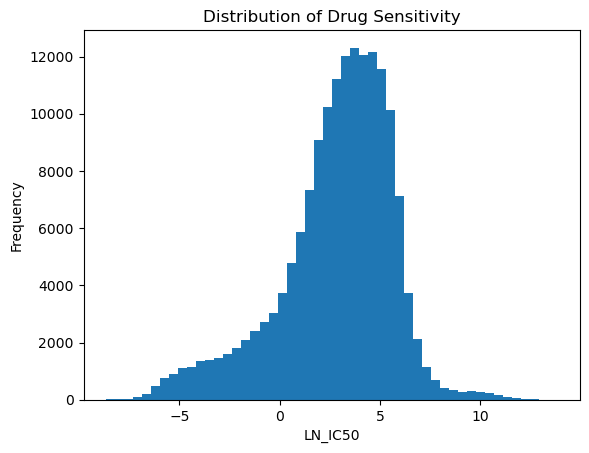

In [56]:
plt.hist(gdsc['LN_IC50'], bins=50)
plt.xlabel('LN_IC50')
plt.ylabel('Frequency')
plt.title('Distribution of Drug Sensitivity')
plt.show()

## 2. Visualisation of drug sensitivity across cancer types

In [57]:
cancer_drug = (
    gdsc.groupby(["TCGA_DESC", "DRUG_NAME"])["LN_IC50"]
    .mean()
    .reset_index()
)
cancer_drug.shape

(7240, 3)

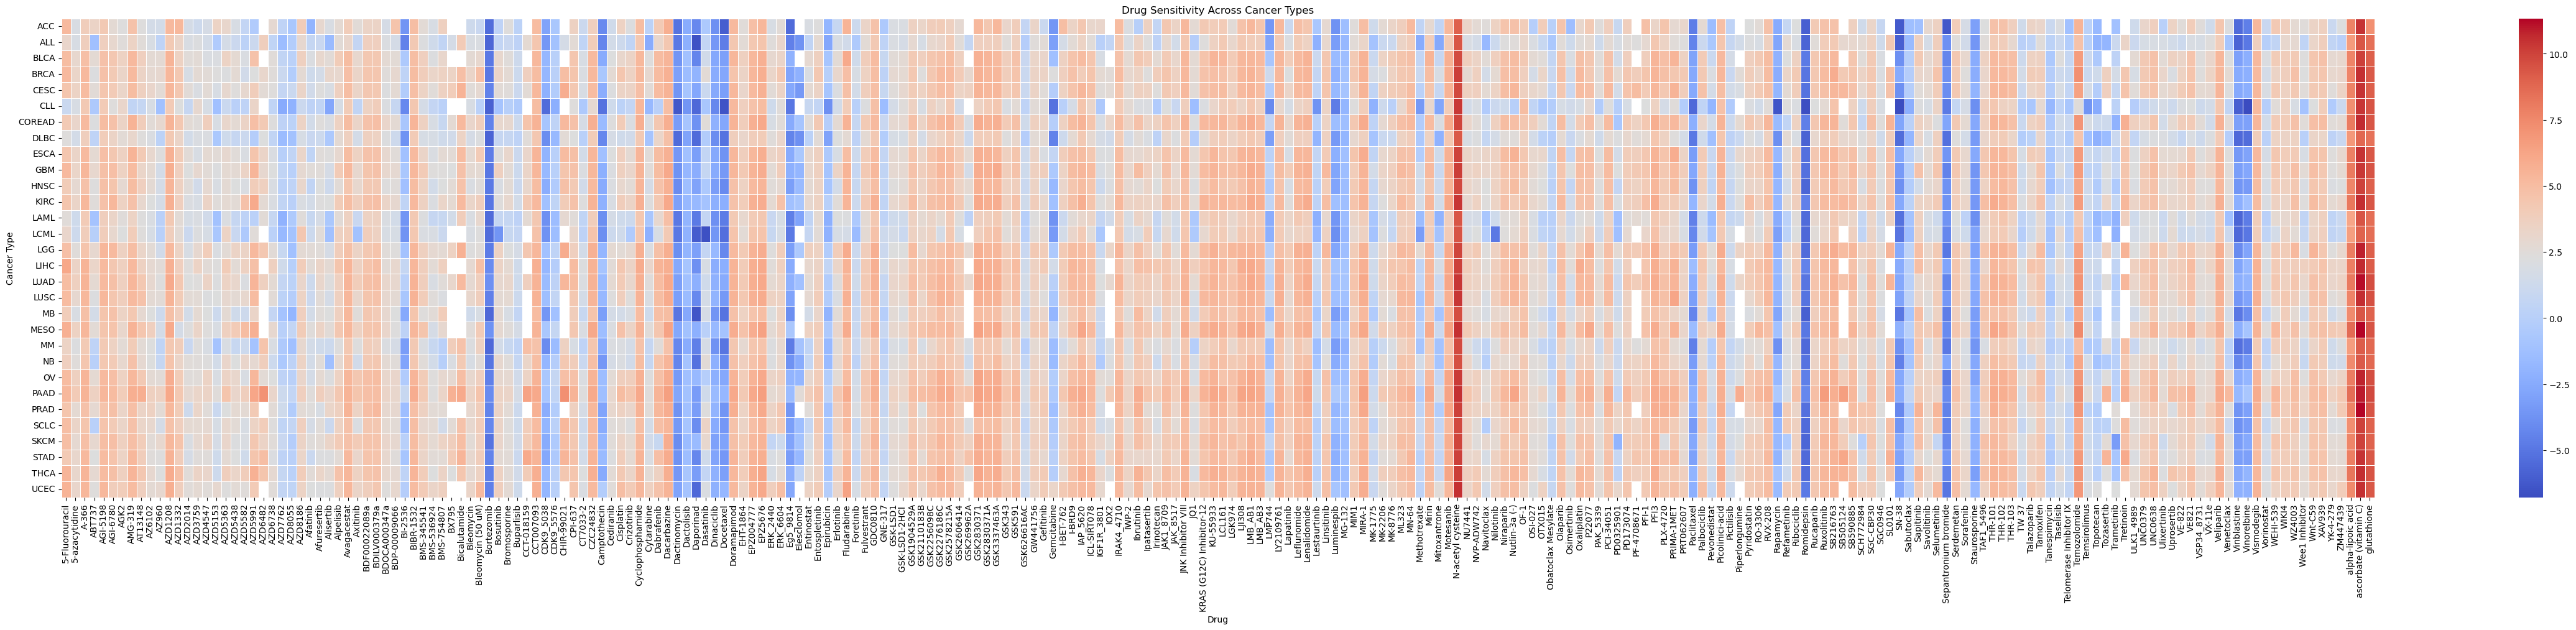

In [58]:
heatmap_data = cancer_drug.pivot(
    index="TCGA_DESC",
    columns="DRUG_NAME",
    values="LN_IC50"
)

plt.figure(figsize=(60,10))

sns.heatmap(
    heatmap_data,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Drug Sensitivity Across Cancer Types")
plt.xlabel("Drug")
plt.ylabel("Cancer Type")

plt.show()

**Interpretation**

The drug sensitivity across the cancer types was visualised using a heatmap. The drugs were plotted against the cancer types to see the pattern. Blue represents higher sensitivity(lower IC50), and red represents lower sensitivity (higher IC50). The white cells represent that the drug was not tested for that cancer. The heatmap is more clumsy due to the larger number of drugs. So, filtration of top sensitive drugs is required for a much cleaner plot. 

## Filteration of top sensitive drugs and visualisation through heatmap

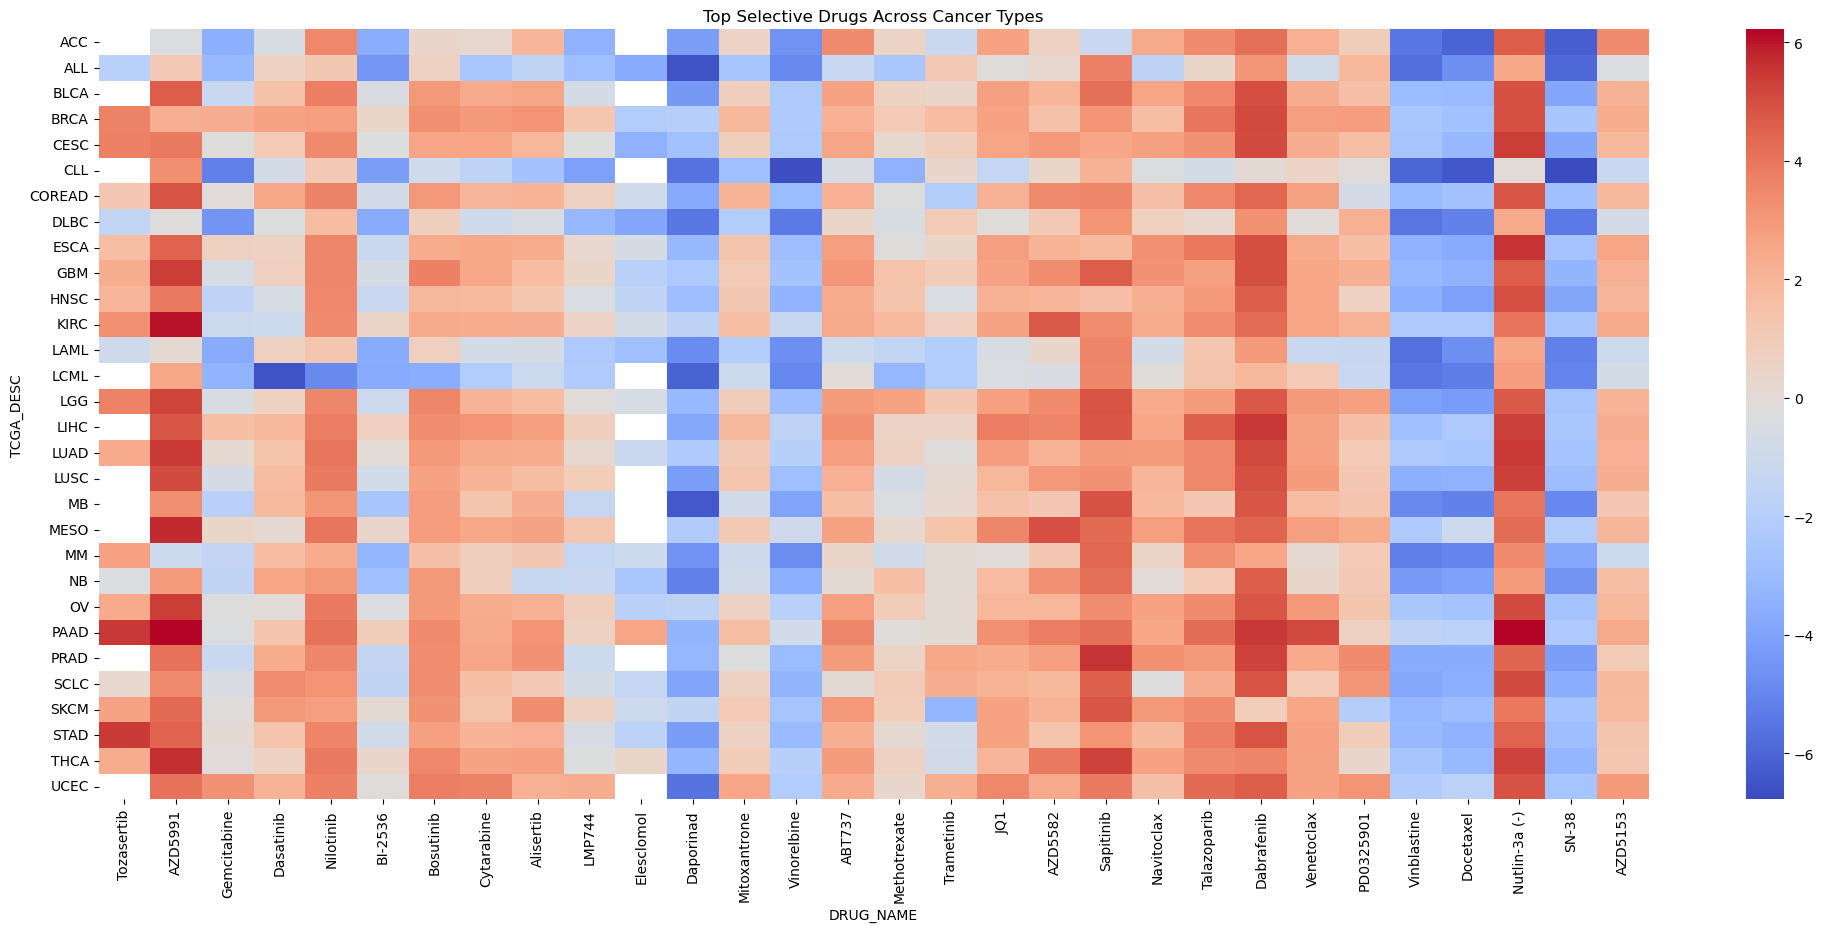

In [59]:
top_drugs = (
    cancer_drug.groupby("DRUG_NAME")["LN_IC50"]
    .std()
    .sort_values(ascending=False)
    .head(30)
    .index
)
filtered_heatmap = heatmap_data[top_drugs]
plt.figure(figsize=(25,10))

sns.heatmap(
    filtered_heatmap,
    cmap="coolwarm"
)

plt.xticks(rotation=90)

plt.title("Top Selective Drugs Across Cancer Types")

plt.show()

After filtering the top sensitive drugs using standard deviation values, a heatmap was plotted again. This heatmap shows drug sensitivity across the cancer types. The drugs Tozasertib, AZD5991, Gemcitabine, Dasatinib and Nilotinib show more variable sensitivity across the cancer types compared to other drugs. That is, they have lower IC50 values in certain cancer types than others. This shows that certain drugs are more sensitive in certain cancer types. 

## Identification of the most selective drugs across Cancer types

In [60]:
drug_selectivity = (
    cancer_drug.groupby("DRUG_NAME")["LN_IC50"]
    .std()
    .sort_values(ascending=False)
)

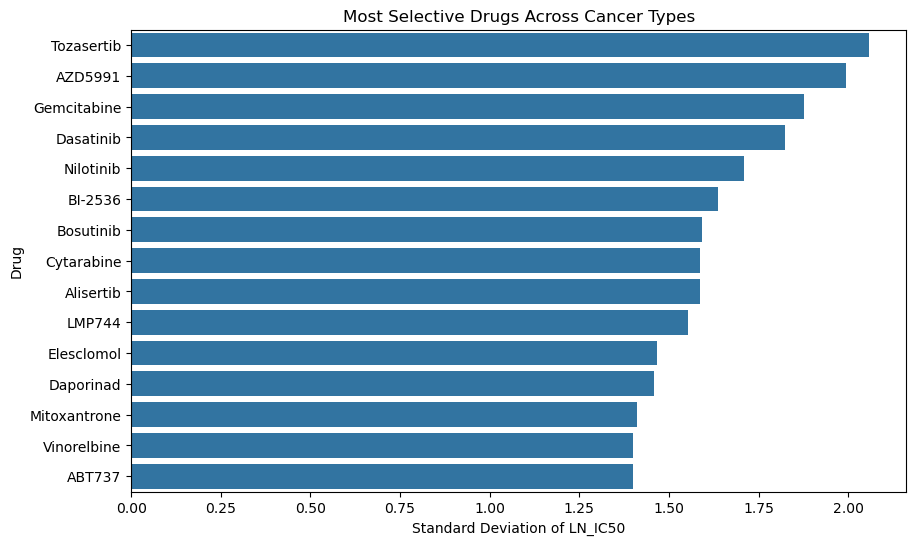

In [61]:
top_variable = drug_selectivity.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_variable.values,
    y=top_variable.index
)

plt.xlabel("Standard Deviation of LN_IC50")
plt.ylabel("Drug")
plt.title("Most Selective Drugs Across Cancer Types")

plt.show()

The most selective drugs across the cancer types were identified and visualised using a bar plot. The plot shows the top 15 selective drugs( these drugs have more sensitivity in certain cancer types). This was identified using the standard deviation of IC50 values, which shows the variability of the drug response across the cancers. The tozasertib drug shows a higher standard deviation (more variability in response), meaning that the drug works well only in certain cancer types.

## Visualisation of cancer-specific response to the drug Tozasertib

In [62]:
Tozasertib = gdsc[gdsc["DRUG_NAME"] == "Tozasertib"]
Tozasertib_summary = (
    Tozasertib.groupby("TCGA_DESC")["LN_IC50"]
    .mean()
    .sort_values()
)

Tozasertib_summary

TCGA_DESC
ALL      -1.882188
DLBC     -1.474129
LAML     -0.955036
NB       -0.372859
SCLC      0.264204
COREAD    1.235339
ESCA      1.623229
HNSC      1.985349
GBM       2.284202
THCA      2.333179
OV        2.360501
LUAD      2.456204
SKCM      2.633545
MM        2.701548
KIRC      3.226426
BRCA      3.638272
LGG       3.655860
CESC      3.697822
STAD      5.439479
PAAD      5.493971
Name: LN_IC50, dtype: float64

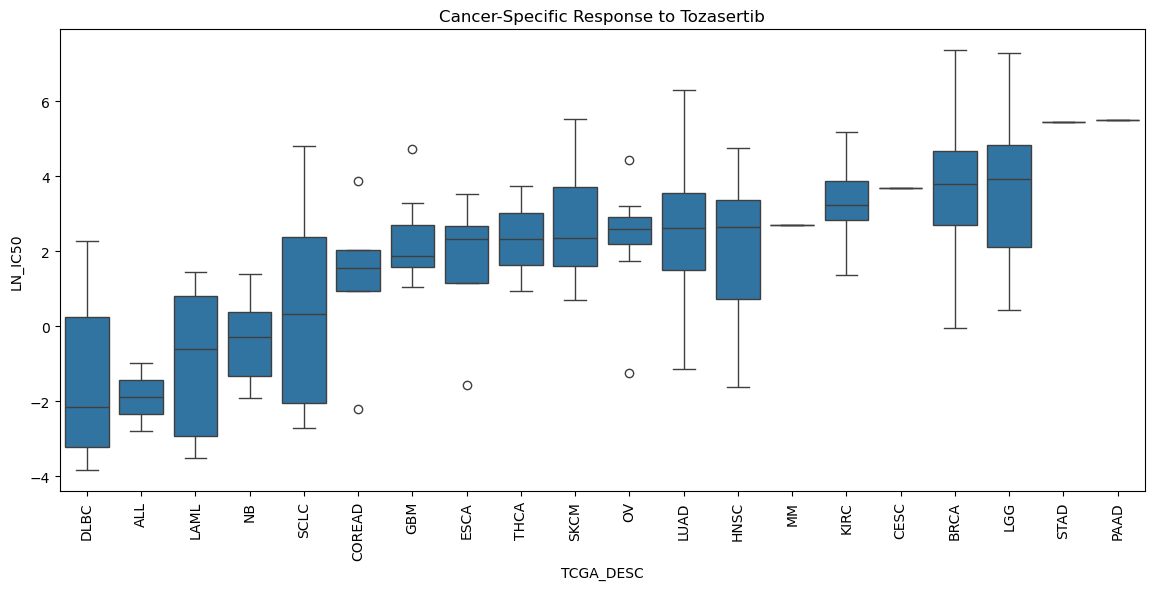

In [63]:
order = (
    Tozasertib.groupby("TCGA_DESC")["LN_IC50"]
    .median()
    .sort_values()
    .index)
plt.figure(figsize=(14,6))

sns.boxplot(
    data=Tozasertib,
    x="TCGA_DESC",
    y="LN_IC50",
    order=order
)

plt.xticks(rotation=90)

plt.title("Cancer-Specific Response to Tozasertib")

plt.show()

Taking the most sensitive drug tozasertib as an example, its response across the cancer types was visualised using a box plot. We can conclude that the drug works well with low IC50 values in the DLBC and ALL cancer types compared to other types. 

## Identification of Most Drug-Sensitive Cancer Types

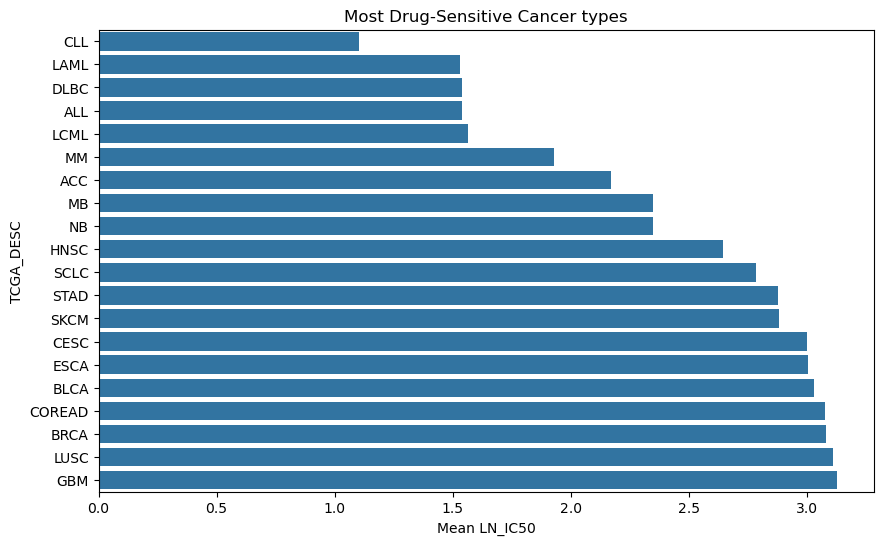

In [64]:
cancer_type_sensitivity = (
    gdsc.groupby("TCGA_DESC")["LN_IC50"]
    .mean()
    .sort_values()
)
top_sensitive = cancer_type_sensitivity.head(20)

top_sensitive
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_sensitive.values,
    y=top_sensitive.index
)

plt.xlabel("Mean LN_IC50")

plt.title("Most Drug-Sensitive Cancer types")

plt.show()

## Identification of Most Selective response Cancer Types

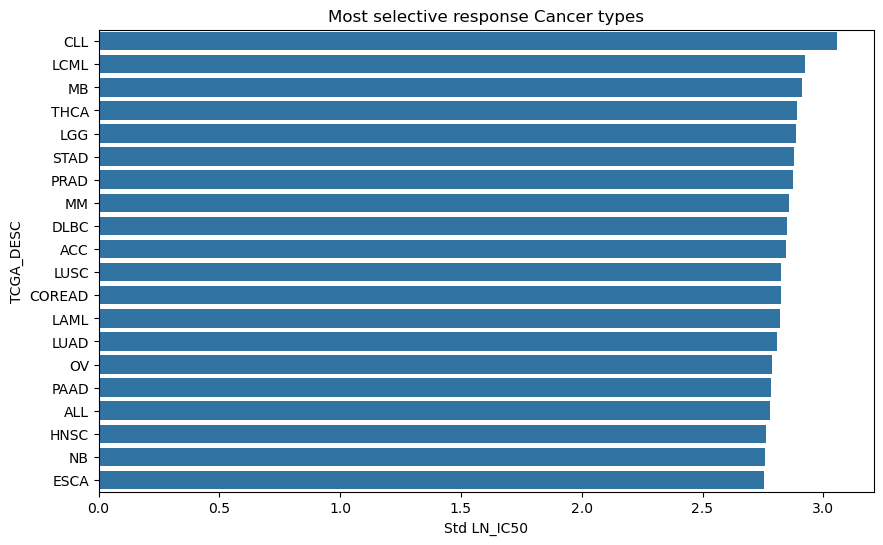

In [65]:
cancer_type_sensitivity = (
    gdsc.groupby("TCGA_DESC")["LN_IC50"]
    .std()
    .sort_values(ascending=False)
)
top_sensitive = cancer_type_sensitivity.head(20)

top_sensitive
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_sensitive.values,
    y=top_sensitive.index
)

plt.xlabel("Std LN_IC50")

plt.title("Most selective response Cancer types")

plt.show()

Most drug-sensitive (broadly sensitive to drugs) and drug-selective (strong response to only certain drugs) cancer types were identified using the mean and standard deviation of IC50 values. The cancer type CLL is both sensitive and selective to drugs. LAML, DLBC, and ALL are also more drug-sensitive cancer types.

## Identification of the best and the worst cell line response to drugs

In [66]:
cellline_drug_response = (
    gdsc.groupby(["CELL_LINE_NAME", "DRUG_NAME"])["LN_IC50"]
    .mean()
    .reset_index()
)

In [67]:
best_cellline_per_drug = (
    cellline_drug_response.loc[
        cellline_drug_response.groupby("DRUG_NAME")["LN_IC50"].idxmin()
    ]
)

best_cellline_per_drug.head(10)

,CELL_LINE_NAME,DRUG_NAME,LN_IC50
8314,BC-3,5-Fluorouracil,-0.807415
140108,SU-DHL-5,5-azacytidine,-0.904855
73671,LOXIMVI,A-366,1.252219
134314,SK-MM-2,ABT737,-5.310295
84307,MOLT-13,AGI-5198,2.259293
8088,BC-1,AGI-6780,1.585496
154145,VMRC-MELG,AGK2,0.771159
58364,JVM-3,AMG-319,-0.279615
117091,P31-FUJ,AT13148,-0.551350
71101,LB996-RCC,AZ6102,0.478866


In [68]:
worst_cellline_per_drug = (
    cellline_drug_response.loc[
        cellline_drug_response.groupby("DRUG_NAME")["LN_IC50"].idxmax()
    ]
)

worst_cellline_per_drug.head(10)

,CELL_LINE_NAME,DRUG_NAME,LN_IC50
116034,OVKATE,5-Fluorouracil,10.174480
7315,AsPC-1,5-azacytidine,8.516161
118091,PANC-04-03,A-366,8.439902
13105,C3A,ABT737,6.845705
7318,AsPC-1,AGI-5198,8.700636
107881,NMC-G1,AGI-6780,8.144752
116039,OVKATE,AGK2,6.973377
118095,PANC-04-03,AMG-319,8.645224
11138,BT-483,AT13148,8.309792
154510,VMRC-RCZ,AZ6102,6.841416


Analysing the drug response in the cell lines, the best and worst responding cell line for each drug were identified. 

## Vizualisation of Cell-line specific drug response

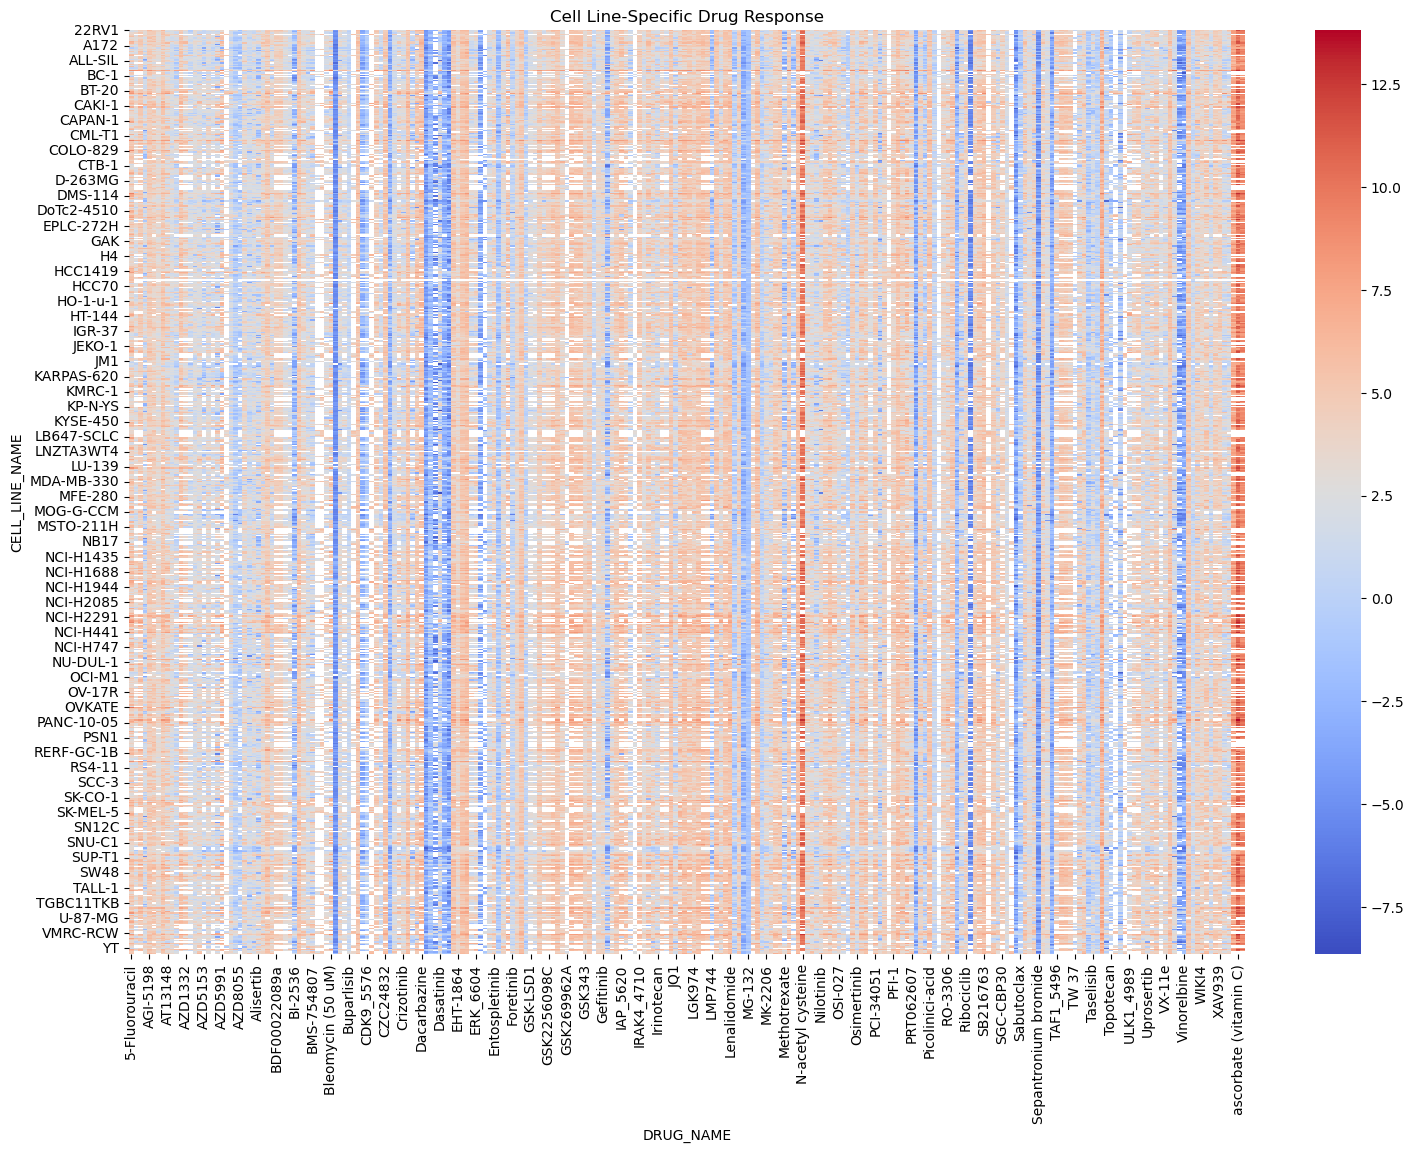

In [69]:
heatmap_cellline = cellline_drug_response.pivot(
    index="CELL_LINE_NAME",
    columns="DRUG_NAME",
    values="LN_IC50"
)
plt.figure(figsize=(18,12))

sns.heatmap(
    heatmap_cellline,
    cmap="coolwarm"
)

plt.title("Cell Line-Specific Drug Response")

plt.show()

The drug response against the cell lines was visualised using a heatmap. Blue represents higher sensitivity(lower IC50), and red represents lower sensitivity (higher IC50). The white cells represent that the drug was not tested for that cell line. The heatmap is more clumsy due to the larger number of drugs. So, filtration of the top sensitive drugs is required for a much cleaner plot. 

## Filteration of top sensitive drugs and visualisation

In [70]:
top_drugs = (
    cellline_drug_response.groupby("DRUG_NAME")["LN_IC50"]
    .std()
    .sort_values(ascending=False)
    .head(25)
    .index
)

filtered_heatmap_cellline = heatmap_cellline[top_drugs]

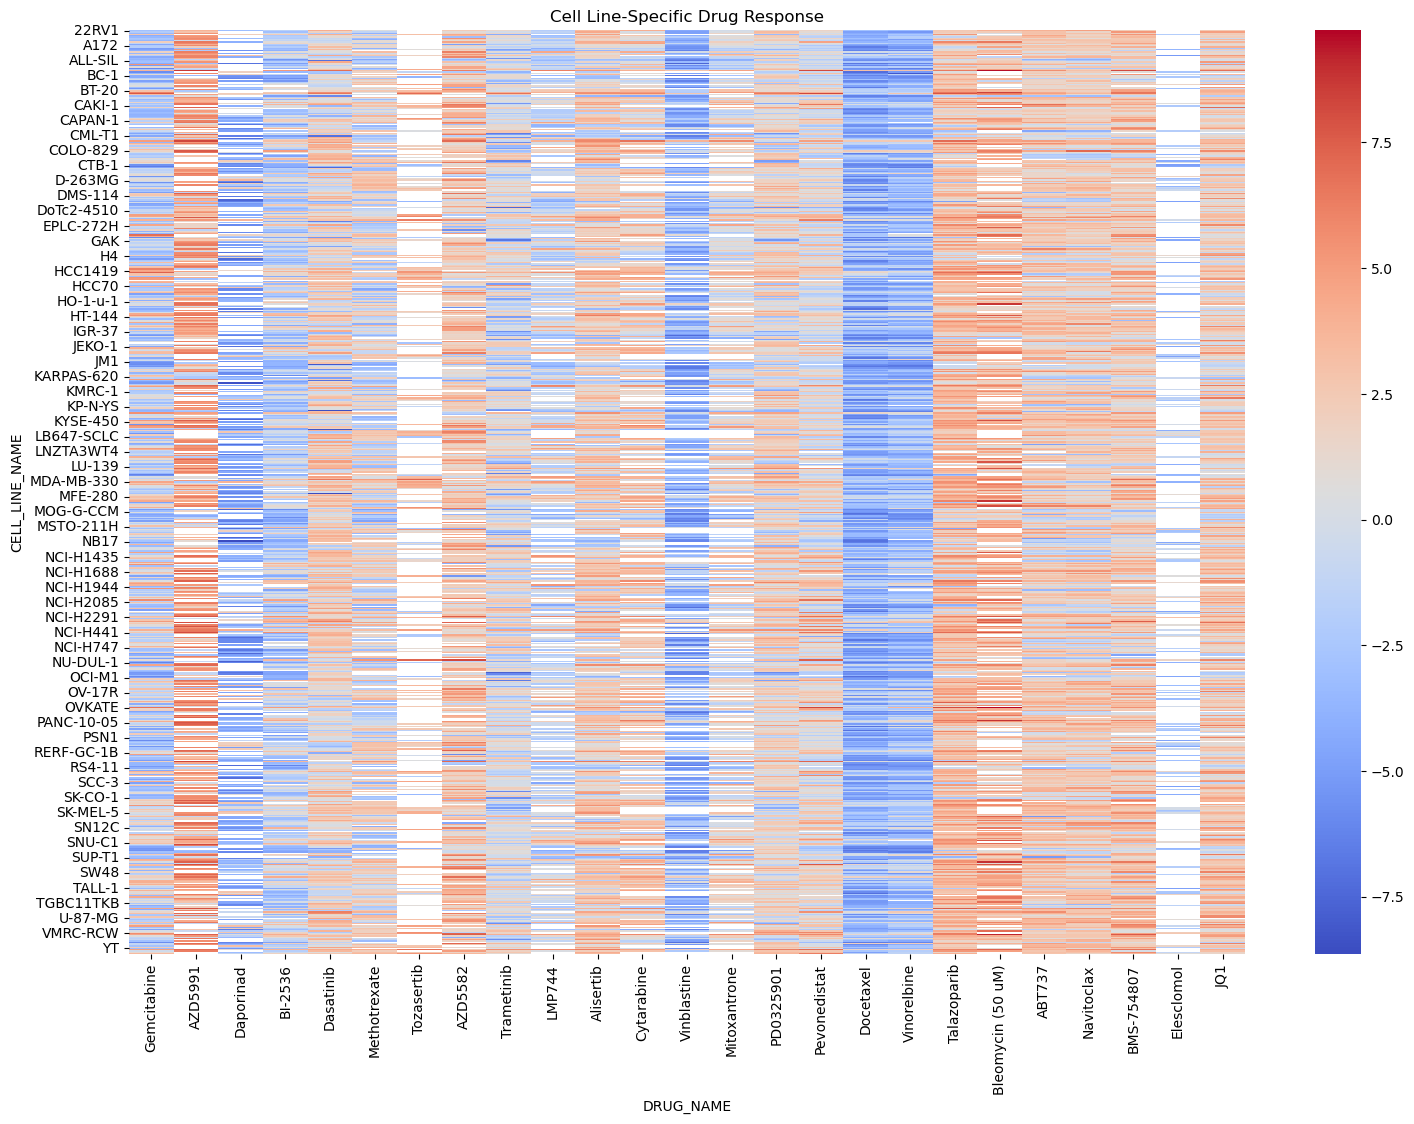

In [71]:
plt.figure(figsize=(18,12))

sns.heatmap(
    filtered_heatmap_cellline,
    cmap="coolwarm"
)

plt.title("Cell Line-Specific Drug Response")

plt.show()

After filtering the top sensitive drugs using standard deviation values, a heatmap was plotted again with the top 25 sensitive drugs. This heatmap shows drug sensitivity across the cell lines. The drugs Gemcitabine, AZD5991, Daporinad, BI-2536 and Dasatinib show the most variable sensitivity across the cell lines compared to other drugs. That is, they have lower IC50 values in certain cell lines than others. This shows that certain drugs are more sensitive in certain cell lines. 

## Identification of most selective drugs across cell lines

In [72]:
drug_variability = (
    cellline_drug_response.groupby("DRUG_NAME")["LN_IC50"]
    .std()
    .sort_values(ascending=False)
)

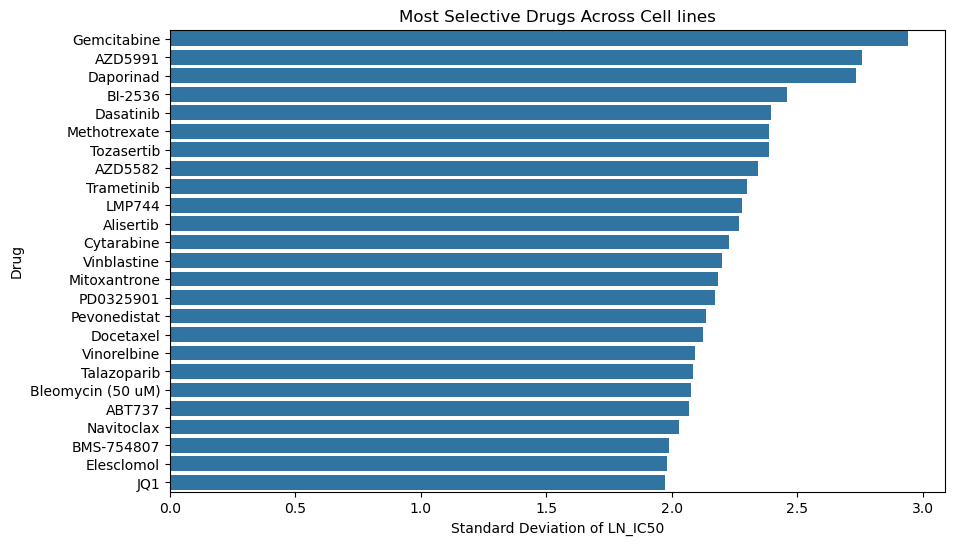

In [73]:
top_variable_cellline = drug_variability.head(25)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_variable_cellline.values,
    y=top_variable_cellline.index
)

plt.xlabel("Standard Deviation of LN_IC50")
plt.ylabel("Drug")
plt.title("Most Selective Drugs Across Cell lines")

plt.show()

The most selective drugs across the cell lines were identified and visualised using a bar plot. The plot shows the top 5 selective drugs( these drugs have more sensitivity in certain cell lines). This was identified using the standard deviation of IC50 values, which shows the variability of the drug response across the cell lines. The Gemcitabine drug shows a higher standard deviation (more variability in response), meaning that the drug works well only in certain cell lines.

## Visualisation of cell line-specific response to the drug Gemcitabine

In [74]:
Gemcitabine = gdsc[gdsc["DRUG_NAME"] == "Gemcitabine"]
gem_summary = (
    Gemcitabine.groupby("CELL_LINE_NAME")["LN_IC50"]
    .mean()
    .sort_values()
)

top_sensitive = gem_summary.head(20)
top_resistant = gem_summary.tail(20)

selected_celllines = pd.concat([top_sensitive, top_resistant])
filtered_gem = Gemcitabine[
    Gemcitabine["CELL_LINE_NAME"].isin(selected_celllines.index)
]

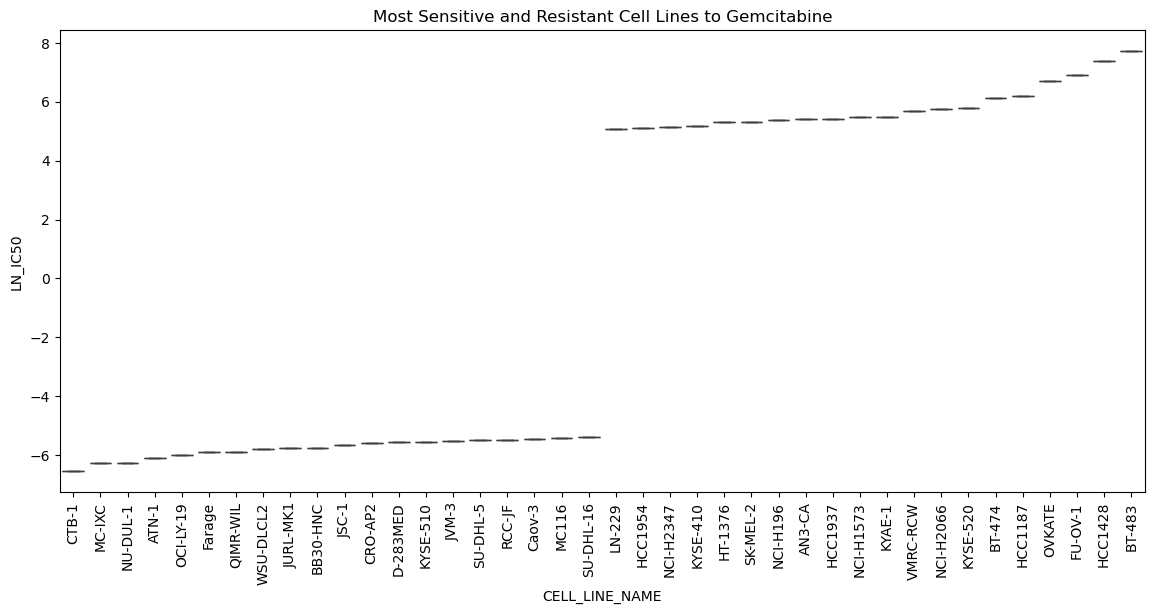

In [75]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=filtered_gem,
    x="CELL_LINE_NAME",
    y="LN_IC50",
    order=selected_celllines.index
)

plt.xticks(rotation=90)

plt.title("Most Sensitive and Resistant Cell Lines to Gemcitabine")

plt.show()

Taking the most sensitive drug gemcitabine as an example, its response across the cell lines was visualised using a box plot. Since there are more than 700 cell lines, the top sensitive and the resistant cell lines were filtered and plotted against IC50 values of gemcitabine. We can conclude that the drug works well with low IC50 values in the CTB-1 and MC-IXC cancer types compared to other types. 

## Visualisation of top drug-sensitive cell lines 

In [76]:
cellline_sensitivity = (
    gdsc.groupby("CELL_LINE_NAME")["LN_IC50"]
    .mean()
    .sort_values()
)
top_sensitive = cellline_sensitivity.head(20)

top_sensitive

CELL_LINE_NAME
MOLM-13       0.251572
DOHH-2        0.484995
SU-DHL-5      0.597210
SU-DHL-16     0.676071
KASUMI-1      0.729258
BV-173        0.852062
RPMI-8402     0.873124
A3-KAW        0.881329
HSC-39        0.918888
WSU-DLCL2     0.921352
SU-DHL-6      0.931398
MONO-MAC-6    0.937378
TALL-1        0.943836
NU-DUL-1      0.965954
JVM-3         0.968679
OCI-AML2      0.986553
ML-2          1.010467
MOLT-16       1.016027
Farage        1.058055
KE-37         1.063428
Name: LN_IC50, dtype: float64

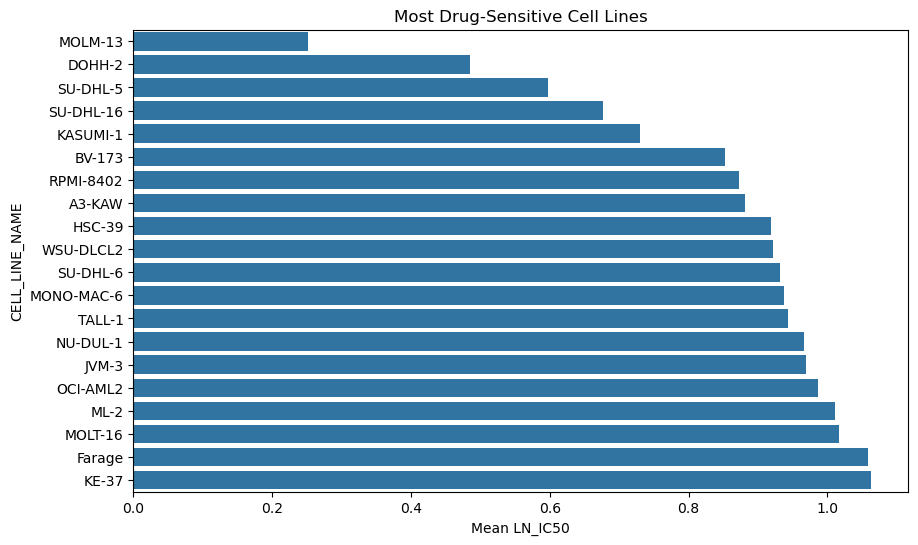

In [77]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_sensitive.values,
    y=top_sensitive.index
)

plt.xlabel("Mean LN_IC50")

plt.title("Most Drug-Sensitive Cell Lines")

plt.show()

## Visualisation of most selective cell lines

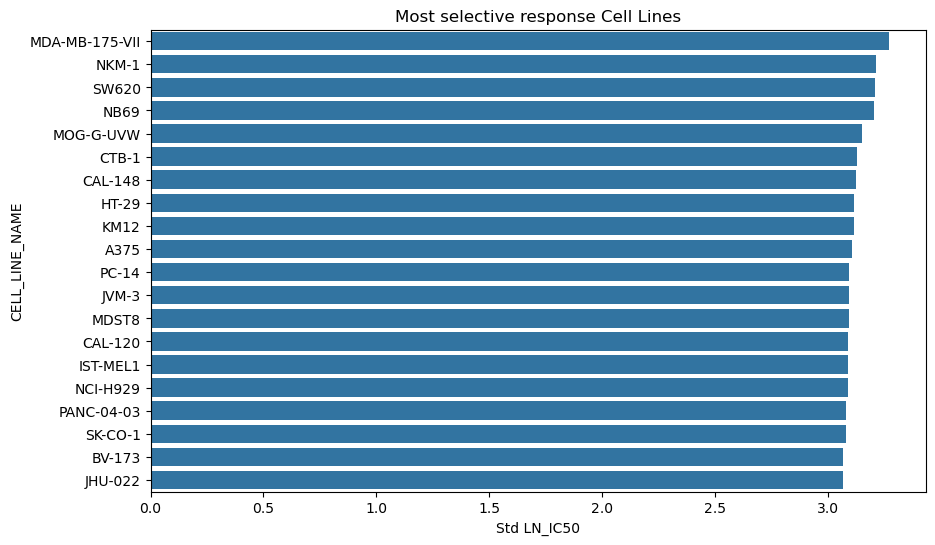

In [78]:
cellline_sensitivity = (
    gdsc.groupby("CELL_LINE_NAME")["LN_IC50"]
    .std()
    .sort_values(ascending=False)
)
top_sensitive = cellline_sensitivity.head(20)

top_sensitive
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_sensitive.values,
    y=top_sensitive.index
)

plt.xlabel("Std LN_IC50")

plt.title("Most selective response Cell Lines")

plt.show()

Most drug-sensitive (broadly sensitive to drugs) and drug-selective (strong response to only certain drugs) cell lines were identified using the mean and standard deviation of IC50 values. The cell lines MOLM-13 and MDA-MB-175-VII were the most sensitive and selective cell lines to drugs. DOHH-2 and SU-DHL-5 are also more drug-sensitive cell lines.

## Cluster plot showing the clustering among the top sensitive and resistant cell lines with drug response

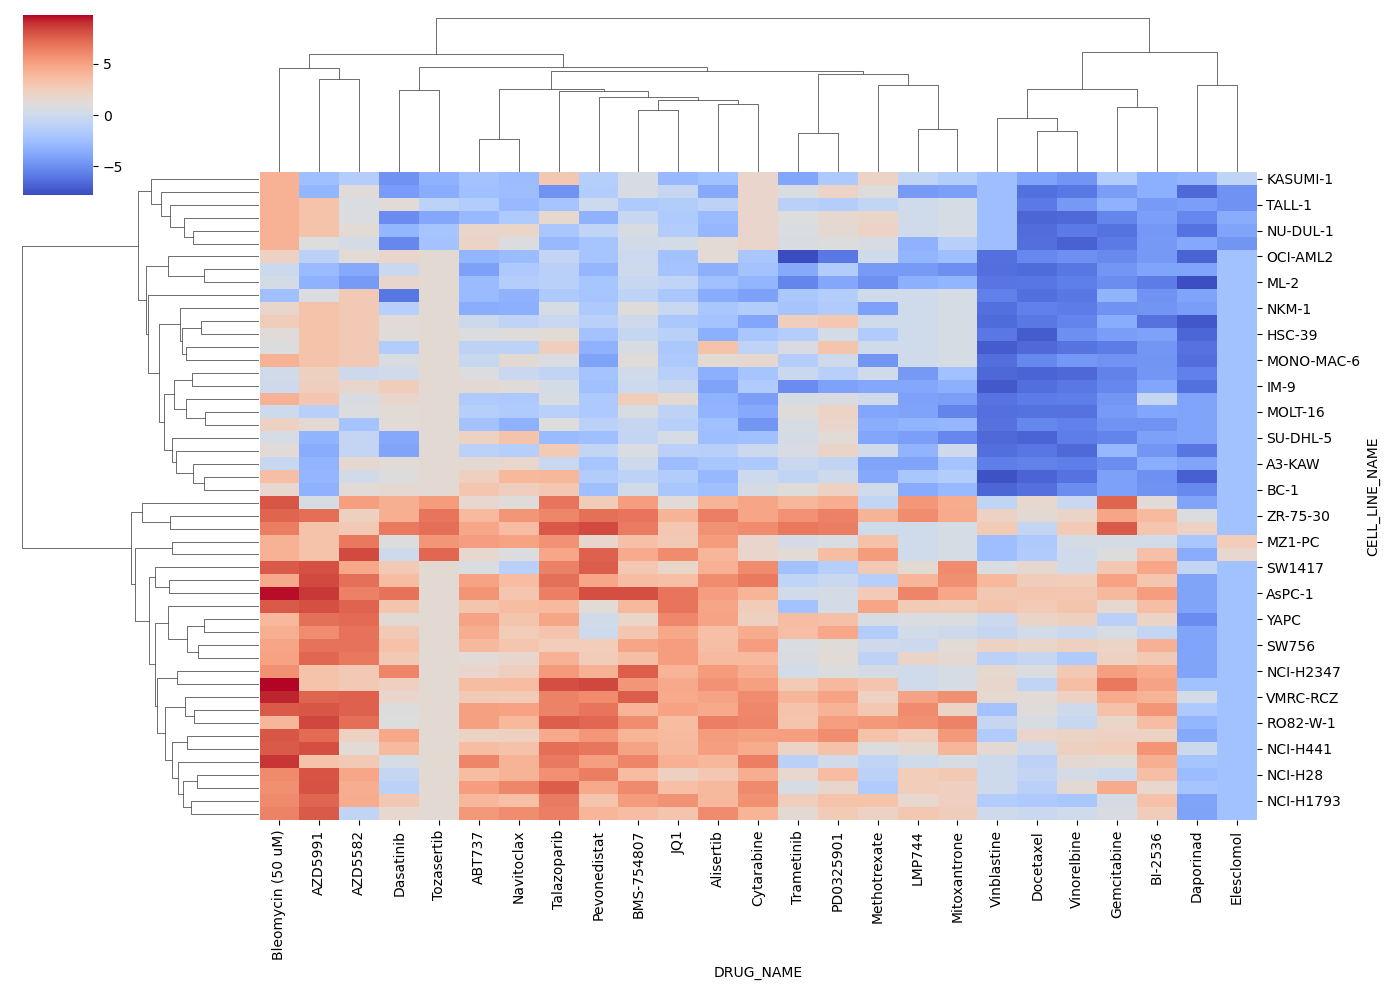

In [79]:
cellline_sensitivity = (
    gdsc.groupby("CELL_LINE_NAME")["LN_IC50"]
    .mean()
    .sort_values()
)
top_sensitive = cellline_sensitivity.head(25)

top_resistant = cellline_sensitivity.tail(25)

selected_celllines = pd.concat([
    top_sensitive,
    top_resistant
]).index
cellline_matrix = gdsc.pivot_table(
    index="CELL_LINE_NAME",
    columns="DRUG_NAME",
    values="LN_IC50",
    aggfunc="mean"
)
top_drugs = (
    gdsc.groupby("DRUG_NAME")["LN_IC50"]
    .std()
    .sort_values(ascending=False)
    .head(25)
    .index
)
filtered_matrix = cellline_matrix.loc[
    selected_celllines,
    top_drugs
]
filtered_matrix = filtered_matrix.fillna(
    filtered_matrix.mean()
)
sns.clustermap(
    filtered_matrix,
    cmap="coolwarm",
    figsize=(14,10)
)

A cluster heatmap was plotted for drug response across cell lines to see the pattern. The top sensitive and resistant cell lines were only used to get a much cleaner plot. The plot clearly shows some grouping of red and blue representing the resistant and sensitive cell lines, respectively. Clustering within the cell lines shows that they respond similarly. Likewise, the clustering among the drugs shows they work similarly. 

# Genomic, transcriptomic and epigenomic influence on drug response

In [80]:
gdsc[["CNA", "Gene Expression", "Methylation"]].head()

,CNA,Gene Expression,Methylation
0,Y,Y,Y
1,Y,Y,Y
2,Y,Y,Y
3,Y,Y,Y
4,Y,Y,Y


In [81]:
gdsc[["CNA", "Gene Expression", "Methylation"]].dtypes

CNA                object
Gene Expression    object
Methylation        object
dtype: object

## Box Plot showing the effect of CNA on drug response

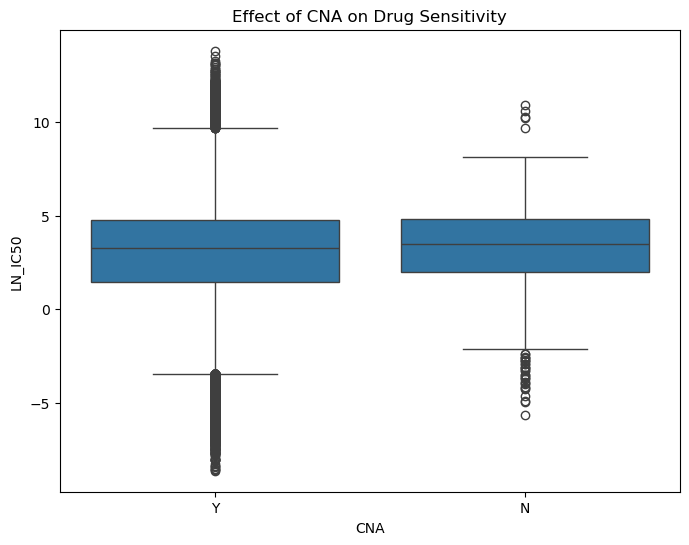

In [82]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=gdsc,
    x="CNA",
    y="LN_IC50"
)

plt.title("Effect of CNA on Drug Sensitivity")

plt.show()

In [83]:
gdsc.groupby("CNA")["LN_IC50"].describe()

,count,mean,std,min,25%,50%,75%,max
CNA,,,,,,,,
N,658.0,3.128990,2.503630,-5.673802,1.979975,3.508225,4.842222,10.914123
Y,161445.0,2.821395,2.837446,-8.642551,1.474040,3.269899,4.767126,13.820189


## Statistical test to identify the significant difference between the two groups

In [84]:
from scipy.stats import ttest_ind

In [85]:
cna_yes = gdsc[gdsc["CNA"] == "Y"]["LN_IC50"]

cna_no = gdsc[gdsc["CNA"] == "N"]["LN_IC50"]
ttest_ind(cna_yes, cna_no)

TtestResult(statistic=np.float64(-2.776360944598976), pvalue=np.float64(0.005497744925679453), df=np.float64(162101.0))

Statistical test gives a p-value = 0.005497744925679454 (<0.05), explaining that there is a statistical difference between the CNA yes group and the CNA no group. The box plot clearly shows that there is a clear difference between the IC50 values of the two groups. Since the IC50 values of the yes group (2.82) are much lower than the no group(3.12), the Copy number (CNA) influences the drug response. A higher copy number can give a better drug response.

## Box Plot showing the effect of Gene Expression on drug response

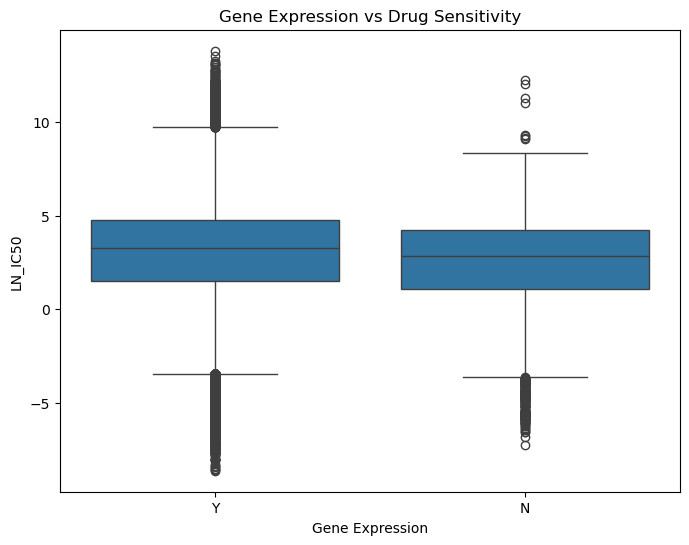

,count,mean,std,min,25%,50%,75%,max
Gene Expression,,,,,,,,
N,3761.0,2.377815,2.703048,-7.258679,1.079113,2.830496,4.225137,12.265135
Y,158342.0,2.833210,2.838479,-8.642551,1.485969,3.283111,4.779837,13.820189


In [86]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=gdsc,
    x="Gene Expression",
    y="LN_IC50"
)

plt.title("Gene Expression vs Drug Sensitivity")

plt.show()
gdsc.groupby("Gene Expression")["LN_IC50"].describe()

## Statistical test to identify the significant difference between the two groups

In [87]:
expr_high = gdsc[gdsc["Gene Expression"] == "Y"]["LN_IC50"]

expr_low = gdsc[gdsc["Gene Expression"] == "N"]["LN_IC50"]

ttest_ind(expr_high, expr_low)

TtestResult(statistic=np.float64(9.734787682590548), pvalue=np.float64(2.1731496680513867e-22), df=np.float64(162101.0))

Statistical test gives a p-value = 2.1731496680513867e-22 (<0.05), explaining that there is a statistical difference between the gene expression yes group and the no group. The box plot clearly shows that there is a clear difference between the IC50 values of the two groups. Since the IC50 values of the yes group (2.8) are much lower than the no group(2.38), the gene expression influences the drug response. 

## Box Plot showing the effect of Methylation on drug response

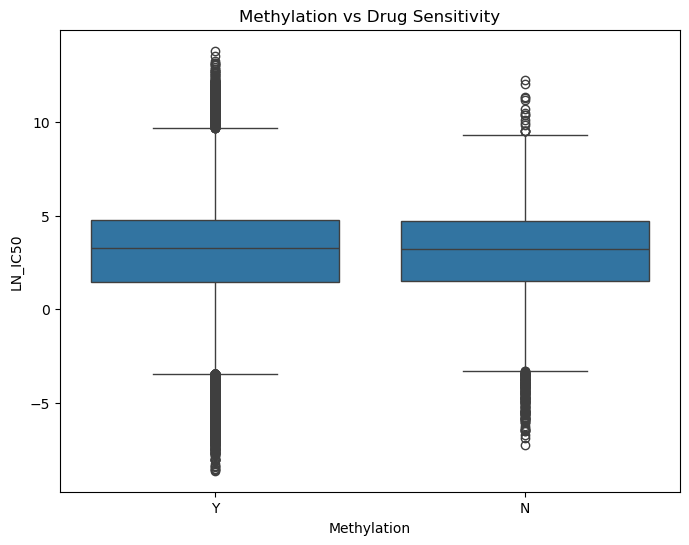

,count,mean,std,min,25%,50%,75%,max
Methylation,,,,,,,,
N,3502.0,2.796813,2.818811,-7.258679,1.494481,3.211147,4.695880,12.265135
Y,158601.0,2.823214,2.836621,-8.642551,1.475704,3.272621,4.769041,13.820189


In [88]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=gdsc,
    x="Methylation",
    y="LN_IC50"
)

plt.title("Methylation vs Drug Sensitivity")

plt.show()
gdsc.groupby("Methylation")["LN_IC50"].describe()

## Statistical test to identify the significant difference between the two groups

In [89]:
Methyl_yes = gdsc[gdsc["Methylation"] == "Y"]["LN_IC50"]

Methyl_no = gdsc[gdsc["Methylation"] == "N"]["LN_IC50"]

ttest_ind(Methyl_yes, Methyl_no)

TtestResult(statistic=np.float64(0.5448776018245742), pvalue=np.float64(0.5858384515515012), df=np.float64(162101.0))

Statistical test gives a p-value = 0.5858384515515012 (>0.05), explaining that there is no statistical difference between the methylation yes group and the no group. The box plot clearly shows that there is no clear difference between the IC50 values of the two groups. Since the IC50 values of the yes group (2.81) are the same as the no group(2.79), the Metylation does not influence the drug response. 

## Analysis of Drug response across the pathways

In [90]:
gdsc['TARGET_PATHWAY'].value_counts()

TARGET_PATHWAY
PI3K/MTOR signaling                  17343
Other                                15237
Other, kinases                       13149
DNA replication                      12400
ERK MAPK signaling                   10176
Genome integrity                      9284
Cell cycle                            8845
Chromatin histone methylation         8152
RTK signaling                         8037
Apoptosis regulation                  7693
Chromatin histone acetylation         6233
Chromatin other                       5981
WNT signaling                         5784
Protein stability and degradation     5362
EGFR signaling                        5119
Mitosis                               4914
IGF1R signaling                       4195
Metabolism                            3667
Hormone-related                       2896
p53 pathway                           2873
Cytoskeleton                          2592
JNK and p38 signaling                 1446
ABL signaling                          

In [91]:
pathway_response = gdsc.groupby(
    'TARGET_PATHWAY'
)['LN_IC50'].mean().sort_values()

pathway_response

TARGET_PATHWAY
Mitosis                             -1.397001
Protein stability and degradation    0.831953
Cell cycle                           1.544684
Apoptosis regulation                 1.777141
DNA replication                      2.098566
PI3K/MTOR signaling                  2.565856
RTK signaling                        2.588115
EGFR signaling                       2.631116
Chromatin histone acetylation        2.680639
ERK MAPK signaling                   2.893182
IGF1R signaling                      2.999228
ABL signaling                        3.124303
Cytoskeleton                         3.215344
Other, kinases                       3.336508
Chromatin other                      3.457902
Other                                3.581629
Genome integrity                     3.765941
Chromatin histone methylation        3.790318
WNT signaling                        4.029785
Hormone-related                      4.213764
p53 pathway                          4.539667
Metabolism         

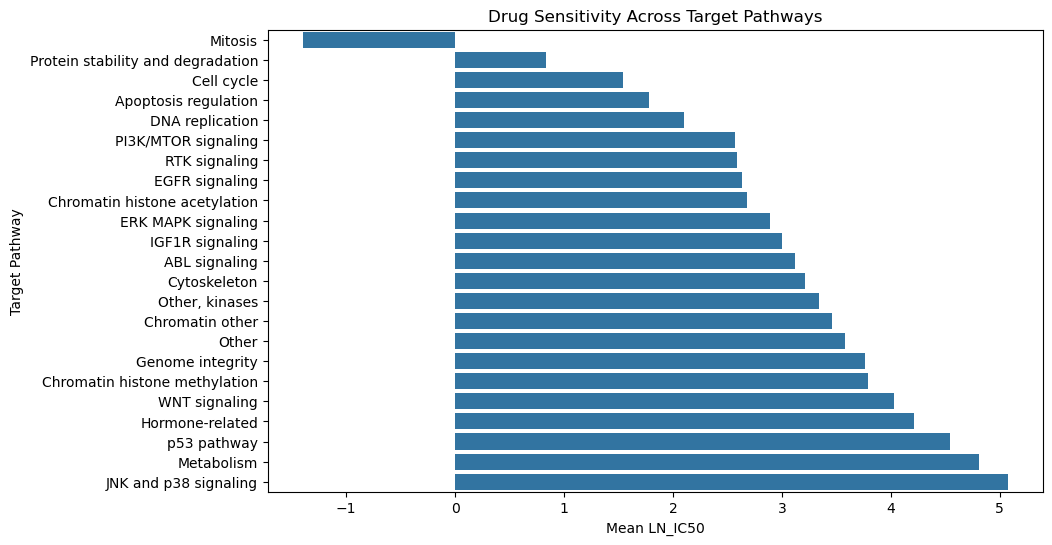

In [92]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=pathway_response.values,
    y=pathway_response.index
)

plt.xlabel("Mean LN_IC50")
plt.ylabel("Target Pathway")
plt.title("Drug Sensitivity Across Target Pathways")

plt.show()

The mean IC50 values were plotted against the pathways. The mitosis pathway shows the lowest IC50 value, explaining that mitosis-inhibiting drugs are more effective. While JNK and p38 signalling pathways show a higher IC50 value (i.e., JNK and p38 signalling pathway drugs show resistance).

In [93]:
heatmap_data = gdsc.pivot_table(
    values='LN_IC50',
    index='TCGA_DESC',
    columns='TARGET_PATHWAY',
    aggfunc='mean'
)

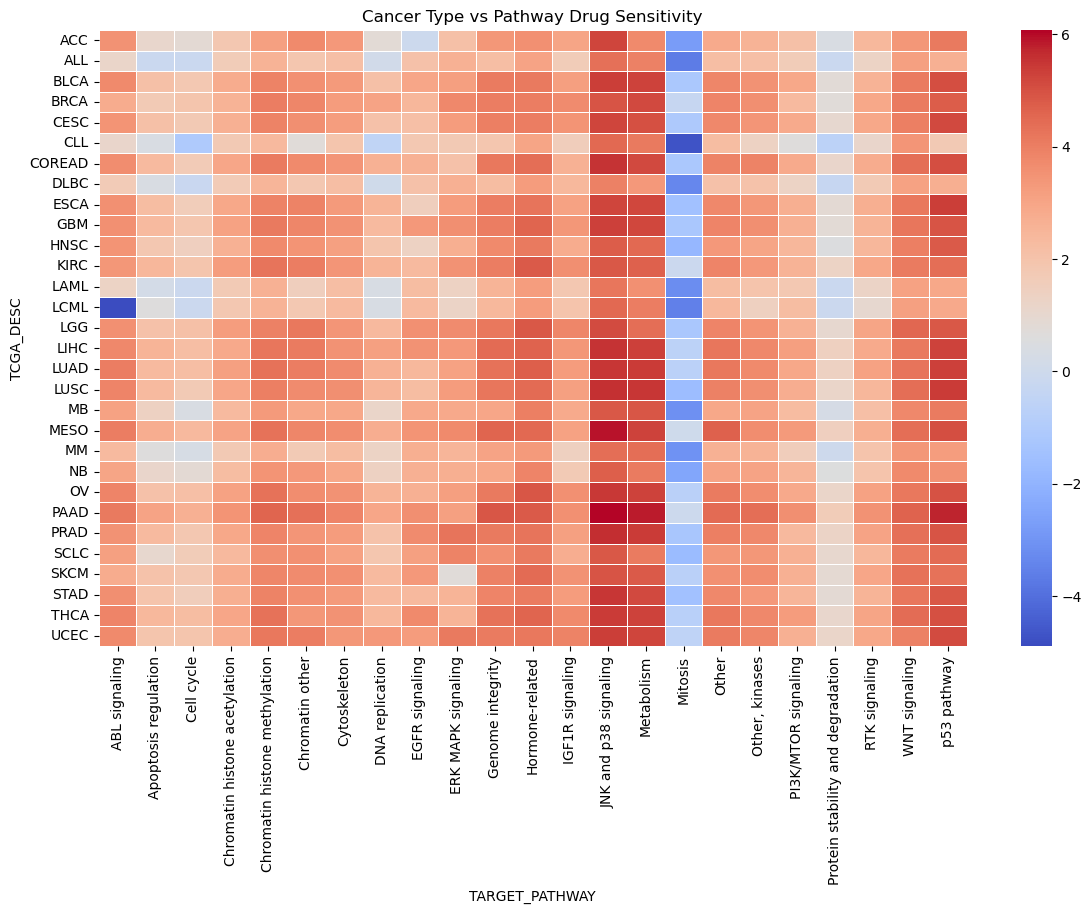

In [94]:
plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Cancer Type vs Pathway Drug Sensitivity")

plt.show()

A heatmap was used to visualise the drug responses in the cancer types against pathways. This clearly shows that in most of the cancer types, the mitosis pathway targeting drugs work better (are more sensitive) than other pathway targeting drugs. We can also see that in the cancer LCML, ABL signal-targeting drugs have a more sensitive response than other drugs.

## Pathway-Level Ranking

In [95]:
pathway_summary = gdsc.groupby(
    'TARGET_PATHWAY'
).agg({
    'LN_IC50': ['mean', 'median', 'std', 'count']
})

pathway_summary

LN_IC50                           
                                       mean    median       std  count
TARGET_PATHWAY                                                        
ABL signaling                      3.124303  3.356439  1.591528    725
Apoptosis regulation               1.777141  2.183364  2.972418   7693
Cell cycle                         1.544684  1.778162  2.810240   8845
Chromatin histone acetylation      2.680639  3.414285  2.877660   6233
Chromatin histone methylation      3.790318  3.804996  1.656897   8152
Chromatin other                    3.457902  3.672895  1.936215   5981
Cytoskeleton                       3.215344  3.176665  1.333452   2592
DNA replication                    2.098566  2.622819  3.340113  12400
EGFR signaling                     2.631116  2.640765  1.617042   5119
ERK MAPK signaling                 2.893182  3.085673  2.145971  10176
Genome integrity                   3.765941  4.093601  1.873051   9284
Hormone-related                    4.213764  4.206840  1.298648   2896
IGF1R signaling                    2.999228  3.120581  1.808367   4195
JNK and p38 signaling              5.071976  5.132515  1.075872   1446
Metabolism                         4.807937  4.827139  3.939324   3667
Mitosis                           -1.397001 -1.995541  3.325051   4914
Other                              3.581629  4.290716  3.535685  15237
Other, kinases                     3.336508  3.571381  2.063823  13149
PI3K/MTOR signaling                2.565856  2.757258  2.359838  17343
Protein stability and degradation  0.831953  0.406124  3.802100   5362
RTK signaling                      2.588115  2.869515  2.416547   8037
WNT signaling                      4.029785  4.021904  1.331447   5784
p53 pathway                        4.539667  4.714016  1.618289   2873

Mitosis pathway targeting drugs are more sensitive (mean IC50 = -1.39), while metabolism targeting drugs are more variable with a higher std =3.9.  

<center>
    <h1 style =">THANK YOU FOR LISTENING
    </h1>
</center>